In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pyemu
import flopy
import platform
from pathlib import Path
import shutil
import pandas as pd

In [2]:
org_ws = Path('../MV_Model_Files/')
new_ws = 'simple_ies'
if "macos" in platform.platform().lower() or "darwin" in platform.platform().lower():
    exe_dir = Path('../bin/mac/')
elif "linux" in platform.platform().lower():
    exe_dir = Path('../bin/linux/')
else:
    exe_dir = Path('../bin/windows/')

In [3]:
if os.path.exists(new_ws):
    shutil.rmtree(new_ws)
shutil.copytree(org_ws, new_ws)
for f in os.listdir(exe_dir):
    shutil.copy2(os.path.join(exe_dir,f),os.path.join(new_ws,f))

In [4]:
sim = flopy.mf6.MFSimulation.load(sim_ws = new_ws)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package oc...
    loading package chd...
    loading package rch...
    loading package riv...
    loading package wel...
    loading package obs...
  loading solution package at...


In [5]:
pyemu.os_utils.run('mf6',cwd=new_ws)

                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                   VERSION 6.3.0 release candidate 07/30/2021
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Dec 29 2021 09:30:50 with Intel(R) Fortran Intel(R) 64
   Compiler for applications running on Intel(R) 64, Version 19.1.3.301 Build
                                20200925_000000

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the autho

In [6]:
for f in ["k_aq.ref","k_clay.ref"]:
    arr = np.loadtxt(os.path.join(new_ws,f))
    arr[:,:] = arr.mean()
    np.savetxt(os.path.join(new_ws,f),arr,fmt="%15.6E")

In [7]:
pyemu.os_utils.run('mf6',cwd=new_ws)

                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                   VERSION 6.3.0 release candidate 07/30/2021
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Dec 29 2021 09:30:50 with Intel(R) Fortran Intel(R) 64
   Compiler for applications running on Intel(R) 64, Version 19.1.3.301 Build
                                20200925_000000

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the autho

In [8]:
#need a spatial reference to use pilot points. this means xoff, yoff, rotation, epsg
m=sim.get_model()
m.modelgrid

xll:0.0; yll:0.0; rotation:0.0; units:feet; lenuni:1

In [9]:
pf = pyemu.utils.PstFrom(original_d=new_ws,
                         new_d='template',
                         remove_existing=True,
                         start_datetime="1-1-2025",
                         spatial_reference=m.modelgrid)

2025-07-21 21:28:18.208915 starting: opening PstFrom.log for logging
2025-07-21 21:28:18.209065 starting PstFrom process
2025-07-21 21:28:18.209602 starting: setting up dirs
2025-07-21 21:28:18.209652 starting: removing existing new_d 'template'
2025-07-21 21:28:18.215660 finished: removing existing new_d 'template' took: 0:00:00.006008
2025-07-21 21:28:18.215679 starting: copying original_d 'simple_ies' to new_d 'template'
2025-07-21 21:28:18.225218 finished: copying original_d 'simple_ies' to new_d 'template' took: 0:00:00.009539
2025-07-21 21:28:18.225362 finished: setting up dirs took: 0:00:00.015760


In [10]:
?pf.add_parameters

Signature:
pf.add_parameters(
    filenames,
    par_type,
    zone_array=None,
    dist_type='gaussian',
    sigma_range=4.0,
    upper_bound=None,
    lower_bound=None,
    transform=None,
    par_name_base='p',
    index_cols=None,
    use_cols=None,
    use_rows=None,
    pargp=None,
    pp_space=10,
    use_pp_zones=False,
    num_eig_kl=100,
    spatial_reference=None,
    geostruct=None,
    datetime=None,
    mfile_fmt='free',
    mfile_skip=None,
    mfile_sep=None,
    ult_ubound=None,
    ult_lbound=None,
    rebuild_pst=False,
    alt_inst_str='inst',
    comment_char=None,
    par_style='multiplier',
    initial_value=None,
)
Docstring:
Add list or array style model input files to PstFrom object.
This method is the main entry point for adding parameters to the
pest interface

Args:
    filenames (`str`): Model input filenames to parameterize. By default filename should give relative
        loction from top level of pest template directory
        (`new_d` as passed to `Ps

In [11]:
k_pars = [f for f in os.listdir(new_ws) if 'k_' in f and f.endswith('.ref')]
k_pars
for f in k_pars:
    pf.add_parameters(f,par_type='constant',upper_bound=20,lower_bound=0.05,pargp="cn-"+f,par_name_base="cn-"+f)

2025-07-21 21:28:18.241602 transform was not passed, setting default tranform to 'log'
2025-07-21 21:28:18.241687 starting: adding constant type m style parameters for file(s) ['k_aq.ref']
2025-07-21 21:28:18.241736 starting: loading array template/k_aq.ref
2025-07-21 21:28:18.242218 finished: loading array template/k_aq.ref took: 0:00:00.000482
2025-07-21 21:28:18.242314 loaded array 'simple_ies/k_aq.ref' of shape (40, 25)
2025-07-21 21:28:18.243078 starting: writing array-style template file 'template/cn-k_aq.ref_inst0_constant.csv.tpl'
2025-07-21 21:28:18.243104 starting: writing template file template/cn-k_aq.ref_inst0_constant.csv.tpl for ['cn-k_aq.ref_inst:0']
2025-07-21 21:28:18.245116 finished: writing template file template/cn-k_aq.ref_inst0_constant.csv.tpl for ['cn-k_aq.ref_inst:0'] took: 0:00:00.002012
2025-07-21 21:28:18.245134 starting: writing array-based template file 'template/cn-k_aq.ref_inst0_constant.csv.tpl'
2025-07-21 21:28:18.246507 finished: adding constant type

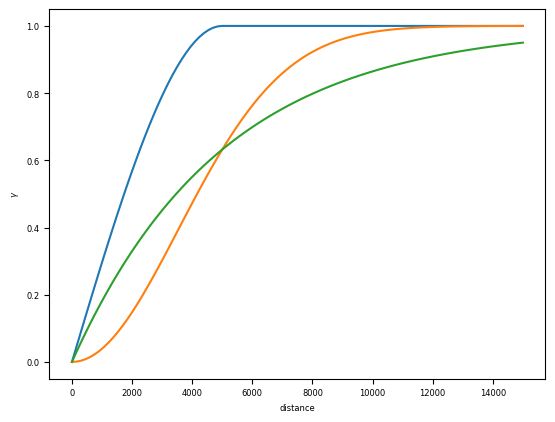

In [52]:
#for pilot points, we first need to build a variogram, which describes the underlying spatial correlation structure of the variable
pp_v = pyemu.geostats.SphVario(contribution=1.0, a=5000) #rule of thumb is that range should be atleast 2x pp spacing (delr= 500, pp space=3)
pp_gs = pyemu.geostats.GeoStruct(variograms=pp_v,transform='log')
ax=pp_gs.plot()
pp_v = pyemu.geostats.GauVario(contribution=1.0, a=5000) 
pp_gs = pyemu.geostats.GeoStruct(variograms=pp_v,transform='log')
ax=pp_gs.plot()
pp_v = pyemu.geostats.ExpVario(contribution=1.0, a=5000) 
pp_gs = pyemu.geostats.GeoStruct(variograms=pp_v,transform='log')
ax=pp_gs.plot()

In [13]:
for f in k_pars:
    base = f.split('.')[0]
    pf.add_parameters(f,par_type='pilotpoint',upper_bound=20,lower_bound=0.05,pp_space=3,geostruct=pp_gs,pargp="pp-"+f,par_name_base="pp-"+f)

2025-07-21 21:28:18.330466 transform was not passed, setting default tranform to 'log'
2025-07-21 21:28:18.330615 starting: adding pilotpoint type m style parameters for file(s) ['k_aq.ref']
2025-07-21 21:28:18.330663 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:5000.0,anisotropy:1.0,bearing:0.0

2025-07-21 21:28:18.330726 starting: loading array template/k_aq.ref
2025-07-21 21:28:18.331070 finished: loading array template/k_aq.ref took: 0:00:00.000344
2025-07-21 21:28:18.331110 loaded array 'simple_ies/k_aq.ref' of shape (40, 25)
2025-07-21 21:28:18.331620 starting: writing array-style template file 'template/pp-k_aq.ref_inst0_pilotpoint.csv.tpl'
2025-07-21 21:28:18.331635 starting: setting up pilot point parameters
2025-07-21 21:28:18.331646 No spatial reference (containing cell spacing) passed.
2025-07-21 21:28:18.331652 OK - using spatial reference in parent object.
2025-07-21 21:28:18.374867 104 pilot point parameters created
2025-07-2

In [14]:
?pf.add_observations

Signature:
pf.add_observations(
    filename,
    insfile=None,
    index_cols=None,
    use_cols=None,
    use_rows=None,
    prefix='',
    ofile_skip=None,
    ofile_sep=None,
    rebuild_pst=False,
    obsgp=None,
    zone_array=None,
    includes_header=True,
)
Docstring:
Add values in output files as observations to PstFrom object

Args:
    filename (`str`): model output file name(s) to set up
        as observations. By default filename should give relative
        loction from top level of pest template directory
        (`new_d` as passed to `PstFrom()`).
    insfile (`str`): desired instructions file filename
    index_cols (`list`-like or `int`): columns to denote are indices for obs
    use_cols (`list`-like or `int`): columns to set up as obs. If None,
        and `index_cols` is not None (i.e list-style obs assumed),
        observations will be set up for all columns in `filename` that
        are not in `index_cols`.
    use_rows (`list`-like or `int`): select only spe

In [15]:
[f for f in os.listdir(new_ws) if f.endswith('.csv')]

['riv.csv', 'at.budget.csv', 'at.wt.csv', 'chd.csv', 'at.csv']

In [16]:
obs_csvs = [f for f in os.listdir(new_ws) if f.endswith('.csv')]
for f in obs_csvs:
    df = pd.read_csv(os.path.join(new_ws,f))
    pf.add_observations(f,index_cols='time',use_cols=df.columns.tolist()[1:])

2025-07-21 21:28:19.457468 starting: adding observations from output file riv.csv
2025-07-21 21:28:19.457578 starting: adding observations from tabular output file '['riv.csv']'
2025-07-21 21:28:19.457652 starting: reading list-style file: template/riv.csv
2025-07-21 21:28:19.458179 finished: reading list-style file: template/riv.csv took: 0:00:00.000527
2025-07-21 21:28:19.458402 starting: building insfile for tabular output file riv.csv
2025-07-21 21:28:19.459491 finished: building insfile for tabular output file riv.csv took: 0:00:00.001089
2025-07-21 21:28:19.459519 starting: adding observation from instruction file 'template/riv.csv.ins'
2025-07-21 21:28:19.460572 finished: adding observation from instruction file 'template/riv.csv.ins' took: 0:00:00.001053
2025-07-21 21:28:19.460799 finished: adding observations from tabular output file '['riv.csv']' took: 0:00:00.003221
2025-07-21 21:28:19.460825 finished: adding observations from output file riv.csv took: 0:00:00.003357
2025-07

In [17]:
for f in k_pars:
    pf.add_observations(f)

2025-07-21 21:28:19.475333 starting: adding observations from output file k_aq.ref
2025-07-21 21:28:19.475434 starting: adding observations from array output file 'k_aq.ref'
2025-07-21 21:28:19.476209 starting: adding observation from instruction file 'template/k_aq.ref.ins'
2025-07-21 21:28:19.480063 finished: adding observation from instruction file 'template/k_aq.ref.ins' took: 0:00:00.003854
2025-07-21 21:28:19.480114 finished: adding observations from array output file 'k_aq.ref' took: 0:00:00.004680
2025-07-21 21:28:19.480138 finished: adding observations from output file k_aq.ref took: 0:00:00.004805
2025-07-21 21:28:19.480148 starting: adding observations from output file k_clay.ref
2025-07-21 21:28:19.480161 starting: adding observations from array output file 'k_clay.ref'
2025-07-21 21:28:19.480650 starting: adding observation from instruction file 'template/k_clay.ref.ins'
2025-07-21 21:28:19.484649 finished: adding observation from instruction file 'template/k_clay.ref.ins'

In [18]:
pf.mod_sys_cmds.append('mf6')

In [20]:
pst = pf.build_pst(filename=os.path.join(pf.new_d,'at.pst'),version=2)

noptmax:0, npar_adj:210, nnz_obs:2048
2025-07-21 21:28:19.504934 forward_run line:pyemu.os_utils.run(r'mf6')



In [21]:
# add in the recharge parameter
r = pst.add_parameters('./simple_ies/at.rch.tpl', pst_path='.')
pars = pst.parameter_data
pars.loc['rch','parval1'] = r.loc['rch'].parval1
pars.loc['rch','parlbnd'] = pars.loc['rch'].parval1 * .8
pars.loc['rch','parubnd'] = pars.loc['rch'].parval1 * 1.2
pars.loc['rch','pargp'] = 'recharge'

pars.loc['rch']

1 pars added from template file ./at.rch.tpl


parnme            rch
partrans          log
parchglim      factor
parval1      0.003641
parlbnd      0.002913
parubnd      0.004369
pargp        recharge
scale             1.0
offset            0.0
dercom              1
i                 NaN
inst              NaN
j                 NaN
pname             NaN
pstyle            NaN
ptype             NaN
zone              NaN
Name: rch, dtype: object

In [22]:
# and the riverbed conductance
rb = pst.add_parameters('./simple_ies/riv.ref.tpl', pst_path='.')
rb

1 pars added from template file ./riv.ref.tpl


,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom
rv1,rv1,log,factor,100000.0,1.100000e-10,1.100000e+10,pargp,1.0,0.0,1


In [23]:
# and the riverbed conductance
pars = pst.parameter_data
pars.loc['rv1','parval1'] = rb.loc['rv1'].parval1
pars.loc['rv1','parlbnd'] = pars.loc['rv1'].parval1 * .1
pars.loc['rv1','parubnd'] = pars.loc['rv1'].parval1 * 10.0
pars.loc['rv1','pargp'] = 'riverbed'

pars.loc['rv1']

parnme             rv1
partrans           log
parchglim       factor
parval1       100000.0
parlbnd        10000.0
parubnd      1000000.0
pargp         riverbed
scale              1.0
offset             0.0
dercom               1
i                  NaN
inst               NaN
j                  NaN
pname              NaN
pstyle             NaN
ptype              NaN
zone               NaN
Name: rv1, dtype: object

In [24]:
pst.write(os.path.join(pf.new_d,'at.pst'),version=2)

noptmax:0, npar_adj:212, nnz_obs:2048


In [ ]:
?pf.draw

In [25]:
#draw prior ensemble that accounts for PP spatial correlation (this is for later for when we want to use iES)
pe = pf.draw(num_reals=300)
pe.enforce()
pe.to_csv(os.path.join(pf.new_d,'prior.csv'))

2025-07-21 21:28:19.538436 starting: drawing realizations
2025-07-21 21:28:19.538807 starting: Drawing 212 non-specsim pars
building diagonal cov
processing  name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:5000.0,anisotropy:1.0,bearing:0.0

working on pargroups ['pp-k_aq.ref']
build cov matrix
done
getting diag var cov 104
scaling full cov by diag var cov
working on pargroups ['pp-k_clay.ref']
build cov matrix
done
getting diag var cov 104
scaling full cov by diag var cov
adding remaining parameters to diagonal
2025-07-21 21:28:19.558954 finished: Drawing 212 non-specsim pars took: 0:00:00.020147
2025-07-21 21:28:19.558995 finished: drawing realizations took: 0:00:00.020559


In [26]:
#load pst
pst = pyemu.Pst(filename=os.path.join(pf.new_d,'at.pst'))

In [27]:
pst.pestpp_options["ies_par_en"] = "prior.csv"
obs = pst.observation_data
obs

,obsnme,obsval,weight,obgnme,i,j,oname,otype,time,usecol
obsnme,,,,,,,,,,
oname:riv.csv_otype:lst_usecol:ds_time:1.0,oname:riv.csv_otype:lst_usecol:ds_time:1.0,-1.002092e+06,1.0,oname:riv.csv_otype:lst_usecol:ds,NaN,NaN,riv.csv,lst,1.0,ds
oname:riv.csv_otype:lst_usecol:pf_time:1.0,oname:riv.csv_otype:lst_usecol:pf_time:1.0,-2.804323e+05,1.0,oname:riv.csv_otype:lst_usecol:pf,NaN,NaN,riv.csv,lst,1.0,pf
oname:at.budget.csv_otype:lst_usecol:chd(chd-1)_in_time:1.0,oname:at.budget.csv_otype:lst_usecol:chd(chd-1)_in_time:1.0,4.919740e+05,1.0,oname:at.budget.csv_otype:lst_usecol:chd(chd-1)_in,NaN,NaN,at.budget.csv,lst,1.0,chd(chd-1)
oname:at.budget.csv_otype:lst_usecol:chd(chd-1)_out_time:1.0,oname:at.budget.csv_otype:lst_usecol:chd(chd-1)_out_time:1.0,6.053681e+04,1.0,oname:at.budget.csv_otype:lst_usecol:chd(chd-1)_out,NaN,NaN,at.budget.csv,lst,1.0,chd(chd-1)
oname:at.budget.csv_otype:lst_usecol:percent_difference_time:1.0,oname:at.budget.csv_otype:lst_usecol:percent_difference_time:1.0,-2.252621e-04,1.0,oname:at.budget.csv_otype:lst_usecol:percent_difference,NaN,NaN,at.budget.csv,lst,1.0,percent
...,...,...,...,...,...,...,...,...,...,...
oname:k_clay_otype:arr_i:9_j:5,oname:k_clay_otype:arr_i:9_j:5,1.809259e+02,1.0,oname:k_clay.ref_otype:arr,9,5,k,arr,NaN,NaN
oname:k_clay_otype:arr_i:9_j:6,oname:k_clay_otype:arr_i:9_j:6,1.809259e+02,1.0,oname:k_clay.ref_otype:arr,9,6,k,arr,NaN,NaN
oname:k_clay_otype:arr_i:9_j:7,oname:k_clay_otype:arr_i:9_j:7,1.809259e+02,1.0,oname:k_clay.ref_otype:arr,9,7,k,arr,NaN,NaN


In [28]:
#test run
pyemu.os_utils.run('pestpp-ies at.pst',cwd='template')



             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team


version: 5.2.21
binary compiled on Jul 14 2025 at 08:35:35

started at 07/21/25 21:28:19
...processing command line: ' ./pestpp-ies at.pst'
...using serial run manager

using control file: "at.pst"
in directory: "/Users/kmarkovich/Desktop/PESTPP_Madison25/notebooks/template"
on host: "ABQ-GQXTTQ9TWR.local"

processing control file at.pst

Note: 'NOPTMAX' == 0, switching to forgiveness mode when checking inputs

noptmax = 0, resetting max_run_fail = 1
checking model IO files...done
              starting serial run manager ...


  ---  initializing  ---  

  ---  'noptmax'=0, running control file parameter values and quitting  ---  
...saving control file parameter ensemble to  at.base.par.csv
...initializing prior parameter covariance matrix
...parcov loaded  from parameter bounds, using par_sigma_range 4
...running control file parameter values



    ---  starting serial 

In [29]:
pst.set_res(os.path.join(pf.new_d,"at.base.rei"))

In [30]:
pst.phi

2.6616070244088824e-11

In [31]:
assert pst.phi < 1e-6

In [32]:
#zero everything out for starters
obs.weight = 0

In [33]:
#we need to tell PEST what are the observed values and their weights, to calc the objective function
truth = pd.read_csv(os.path.join(new_ws,'obsvalues.dat'),sep=r'\s+')
truth

,obsnme,obsval,weight,obgnme
0,w01,11.85000,1.000000,headgroup
1,w02,11.35000,1.000000,headgroup
2,w03,11.83000,1.000000,headgroup
3,w04,11.43000,1.000000,headgroup
4,w05,10.50000,1.000000,headgroup
5,w06,10.79000,1.000000,headgroup
6,w07,9.13000,1.000000,headgroup
7,w08,8.79000,1.000000,headgroup
8,w09,8.83000,1.000000,headgroup
9,w10,10.64000,1.000000,headgroup


In [34]:
obs["standard_deviation"] = np.nan
for i,stuff in truth.iterrows():
    if "headgroup" in stuff.obgnme or "headdiffgroup" in stuff.obgnme or "riv" in stuff.obgnme:
        obs.loc[obs.obsnme.str.contains(stuff.obsnme),'obsval'] = stuff.obsval
        obs.loc[obs.obsnme.str.contains(stuff.obsnme),'weight'] = stuff.weight
        obs.loc[obs.obsnme.str.contains(stuff.obsnme),'obgnme'] = stuff.obgnme
        if "headdiff" in stuff.obgnme:
            obs.loc[obs.obsnme.str.contains(stuff.obsnme),'standard_deviation'] = np.abs(stuff.obsval) * 0.15 
        elif "headgroup" in stuff.obgnme:
            obs.loc[obs.obsnme.str.contains(stuff.obsnme),'standard_deviation'] = 1.0
        else:
            obs.loc[obs.obsnme.str.contains(stuff.obsnme),'standard_deviation'] = np.abs(stuff.obsval) * 0.1

/var/folders/z3/q69sm_6d715fmszm_kq6g7b00000gq/T/ipykernel_55700/1584007757.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.01' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


In [35]:
obs.loc[obs.weight>0]

,obsnme,obsval,weight,obgnme,i,j,oname,otype,time,usecol,standard_deviation
obsnme,,,,,,,,,,,
oname:riv.csv_otype:lst_usecol:ds_time:1.0,oname:riv.csv_otype:lst_usecol:ds_time:1.0,-798092.00,0.000013,rivgroup,NaN,NaN,riv.csv,lst,1.0,ds,79809.2000
oname:riv.csv_otype:lst_usecol:pf_time:1.0,oname:riv.csv_otype:lst_usecol:pf_time:1.0,-96402.00,0.000104,rivgroup,NaN,NaN,riv.csv,lst,1.0,pf,9640.2000
oname:at.wt.csv_otype:lst_usecol:u01_time:1.0,oname:at.wt.csv_otype:lst_usecol:u01_time:1.0,12.05,1.000000,headgroup,NaN,NaN,at.wt.csv,lst,1.0,u01,1.0000
oname:at.wt.csv_otype:lst_usecol:u02_time:1.0,oname:at.wt.csv_otype:lst_usecol:u02_time:1.0,11.63,1.000000,headgroup,NaN,NaN,at.wt.csv,lst,1.0,u02,1.0000
oname:at.wt.csv_otype:lst_usecol:u03_time:1.0,oname:at.wt.csv_otype:lst_usecol:u03_time:1.0,12.15,1.000000,headgroup,NaN,NaN,at.wt.csv,lst,1.0,u03,1.0000
oname:at.wt.csv_otype:lst_usecol:u04_time:1.0,oname:at.wt.csv_otype:lst_usecol:u04_time:1.0,11.44,1.000000,headgroup,NaN,NaN,at.wt.csv,lst,1.0,u04,1.0000
oname:at.wt.csv_otype:lst_usecol:u05_time:1.0,oname:at.wt.csv_otype:lst_usecol:u05_time:1.0,10.86,1.000000,headgroup,NaN,NaN,at.wt.csv,lst,1.0,u05,1.0000
oname:at.wt.csv_otype:lst_usecol:u06_time:1.0,oname:at.wt.csv_otype:lst_usecol:u06_time:1.0,10.80,1.000000,headgroup,NaN,NaN,at.wt.csv,lst,1.0,u06,1.0000
oname:at.wt.csv_otype:lst_usecol:u07_time:1.0,oname:at.wt.csv_otype:lst_usecol:u07_time:1.0,9.16,1.000000,headgroup,NaN,NaN,at.wt.csv,lst,1.0,u07,1.0000


In [36]:
obs.loc[obs.weight>0,:].describe()

,obsval,weight,standard_deviation
count,36.000000,36.000000,36.000000
mean,-24840.064444,0.861948,2485.568042
std,133527.006534,0.348628,13352.401759
min,-798092.000000,0.000013,0.003000
25%,3.825000,1.000000,1.000000
50%,8.195000,1.000000,1.000000
75%,10.792500,1.000000,1.000000
max,12.150000,1.000000,79809.200000


In [37]:
pst.observation_data = obs
pst.write(os.path.join(pf.new_d,'at.pst'),version=2)

noptmax:0, npar_adj:212, nnz_obs:36


In [38]:
pyemu.os_utils.run('pestpp-ies at.pst',cwd='template')



             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team


version: 5.2.21
binary compiled on Jul 14 2025 at 08:35:35

started at 07/21/25 21:28:21
...processing command line: ' ./pestpp-ies at.pst'
...using serial run manager

using control file: "at.pst"
in directory: "/Users/kmarkovich/Desktop/PESTPP_Madison25/notebooks/template"
on host: "ABQ-GQXTTQ9TWR.local"

processing control file at.pst

Note: 'NOPTMAX' == 0, switching to forgiveness mode when checking inputs

noptmax = 0, resetting max_run_fail = 1
checking model IO files...done
              starting serial run manager ...


  ---  initializing  ---  

  ---  'noptmax'=0, running control file parameter values and quitting  ---  
...saving control file parameter ensemble to  at.base.par.csv
...initializing prior parameter covariance matrix
...parcov loaded  from parameter bounds, using par_sigma_range 4
...running control file parameter values



    ---  starting serial 

In [39]:
phi= pst.phi
phi

390.09576849555043

In [40]:
pst.parameter_data.loc[:,"parval1"] = pe.loc[pe.index[0],pst.par_names].values

In [41]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,i,inst,j,pname,pstyle,ptype,zone
parnme,,,,,,,,,,,,,,,,,
pname:cn-k_aq.ref_inst:0_ptype:cn_pstyle:m,pname:cn-k_aq.ref_inst:0_ptype:cn_pstyle:m,log,factor,0.910676,0.05,20.0,cn-k_aq.ref,1.0,0.0,1,NaN,0,NaN,cn-k,m,cn,NaN
pname:cn-k_clay.ref_inst:0_ptype:cn_pstyle:m,pname:cn-k_clay.ref_inst:0_ptype:cn_pstyle:m,log,factor,2.444199,0.05,20.0,cn-k_clay.ref,1.0,0.0,1,NaN,0,NaN,cn-k,m,cn,NaN
pname:pp-k_aq.ref_inst:0_ptype:pp_pstyle:m_i:1_j:1_zone:1,pname:pp-k_aq.ref_inst:0_ptype:pp_pstyle:m_i:1_j:1_zone:1,log,factor,0.588591,0.05,20.0,pp-k_aq.ref,1.0,0.0,1,1,0,1,pp-k,m,pp,1
pname:pp-k_aq.ref_inst:0_ptype:pp_pstyle:m_i:1_j:4_zone:1,pname:pp-k_aq.ref_inst:0_ptype:pp_pstyle:m_i:1_j:4_zone:1,log,factor,0.724949,0.05,20.0,pp-k_aq.ref,1.0,0.0,1,1,0,4,pp-k,m,pp,1
pname:pp-k_aq.ref_inst:0_ptype:pp_pstyle:m_i:1_j:7_zone:1,pname:pp-k_aq.ref_inst:0_ptype:pp_pstyle:m_i:1_j:7_zone:1,log,factor,0.621493,0.05,20.0,pp-k_aq.ref,1.0,0.0,1,1,0,7,pp-k,m,pp,1


In [42]:
pst.write(os.path.join(pf.new_d,"test.pst"),version=2)
pyemu.os_utils.run("pestpp-ies test.pst",cwd=pf.new_d)

noptmax:0, npar_adj:212, nnz_obs:36


             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team


version: 5.2.21
binary compiled on Jul 14 2025 at 08:35:35

started at 07/21/25 21:28:21
...processing command line: ' ./pestpp-ies test.pst'
...using serial run manager

using control file: "test.pst"
in directory: "/Users/kmarkovich/Desktop/PESTPP_Madison25/notebooks/template"
on host: "ABQ-GQXTTQ9TWR.local"

processing control file test.pst

Note: 'NOPTMAX' == 0, switching to forgiveness mode when checking inputs

noptmax = 0, resetting max_run_fail = 1
checking model IO files...done
              starting serial run manager ...


  ---  initializing  ---  

  ---  'noptmax'=0, running control file parameter values and quitting  ---  
...saving control file parameter ensemble to  test.base.par.csv
...initializing prior parameter covariance matrix
...parcov loaded  from parameter bounds, using par_sigma_range 4
...running control file p

In [43]:
pst.set_res(os.path.join(pf.new_d,"test.base.rei"))
pst.phi

841.4483254589984

In [44]:
kobs = obs.loc[obs.obsnme.str.contains("k_aq"),:].copy()
kobs['i'] = kobs.i.astype(int)
kobs['j'] = kobs.j.astype(int)

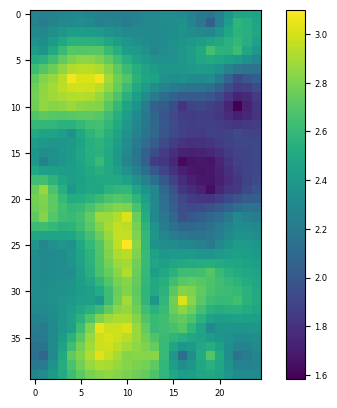

In [45]:
arr = np.zeros((kobs.i.max()+1,kobs.j.max()+1))
arr[kobs.i,kobs.j] = np.log10(pst.res.loc[kobs.obsnme,"modelled"].values)
cb = plt.imshow(arr)
plt.colorbar(cb)

In [46]:
pst = pyemu.Pst(os.path.join(pf.new_d,"at.pst"))
pst.control_data.noptmax = -2
pst.write(os.path.join(pf.new_d,"at.pst"),version=2)
pyemu.os_utils.run("pestpp-ies at.pst",cwd=pf.new_d)

noptmax:-2, npar_adj:212, nnz_obs:36


             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team


version: 5.2.21
binary compiled on Jul 14 2025 at 08:35:35

started at 07/21/25 21:28:22
...processing command line: ' ./pestpp-ies at.pst'
...using serial run manager

using control file: "at.pst"
in directory: "/Users/kmarkovich/Desktop/PESTPP_Madison25/notebooks/template"
on host: "ABQ-GQXTTQ9TWR.local"

processing control file at.pst
checking model IO files...done
              starting serial run manager ...


  ---  initializing  ---  
...using glm algorithm
...using REDSVD for truncated svd solve
...maxsing: 10000000
...eigthresh:  1e-06
...initializing localizer
...not using localization
...using lambda multipliers: 0.1 , 1 , 10 , 
...using lambda scaling factors: 0.75 , 1 , 1.1 , 
...acceptable phi factor:  1.05
...lambda increase factor:  10
...lambda decrease factor:  0.75
...max run fail:  1
...initializing prior parameter co

In [47]:
pst.set_res(os.path.join(pf.new_d,"at.mean.rei"))
pst.phi

457.745100427833

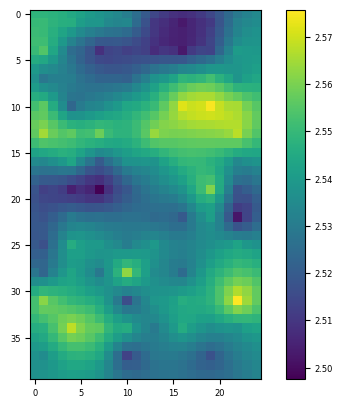

In [48]:
arr = np.zeros((kobs.i.max()+1,kobs.j.max()+1))
arr[kobs.i,kobs.j] = np.log10(pst.res.loc[kobs.obsnme,"modelled"].values)
cb = plt.imshow(arr)
plt.colorbar(cb)